# Mapa de Qualidade do Ar para Lisboa

Este notebook gera um mapa de qualidade do ar para a cidade de Lisboa, utilizando a estrutura de zonas hexagonais do VERUS. Vamos carregar dados de qualidade do ar, processá-los e visualizá-los em um formato compatível com a avaliação de vulnerabilidade espaço-temporal do VERUS.

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from shapely.geometry import Point
from verus.grid import HexagonGridGenerator
import math  # Para cálculos da fórmula haversine

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Carregar Dados de Qualidade do Ar para Lisboa

Primeiro, vamos utilizar a API pública de qualidade do ar de Portugal para obter dados recentes para Lisboa. Se a API não estiver disponível, usaremos dados simulados.

In [2]:
# Função para obter dados de qualidade do ar do arquivo JSON
def obter_dados_qualidade_ar():
    """
    Obtém dados de qualidade do ar para Lisboa a partir do arquivo JSON.
    Retorna um DataFrame com os dados organizados por estação.
    """
    try:
        # Carregar dados do arquivo JSON
        json_path = "../data/risk_layer/lisbon.json"
        print(f"Carregando dados de qualidade do ar de {json_path}")
        
        with open(json_path, 'r') as f:
            dados_json = json.load(f)
        
        print(f"Arquivo JSON carregado com sucesso: {len(dados_json)} registros encontrados")
            
        # Extrair estações de monitoramento de qualidade do ar
        estacoes = {}
        
        # Identificar registros de qualidade do ar (NO2, PM10, PM2.5, O3)
        for registro in dados_json:
            id_registro = registro.get('id', '')
            
            # Verificar se é um registro de qualidade do ar
            if id_registro.startswith('QA'):
                # Extrair o número da estação (últimos 4 dígitos)
                num_estacao = id_registro[-4:]
                endereco = registro.get('address', f'Estação {num_estacao}')
                
                # Inicializar a estação se não existir
                if num_estacao not in estacoes:
                    estacoes[num_estacao] = {
                        'estacao_id': num_estacao,
                        'nome': endereco,
                        'lat': registro.get('coordinates', {}).get('lat', 0),
                        'lon': registro.get('coordinates', {}).get('lng', 0),
                        'NO2': None,
                        'PM10': None,
                        'PM25': None,
                        'O3': None
                    }
                
                # Adicionar o valor do poluente
                if 'PM25' in id_registro:
                    estacoes[num_estacao]['PM25'] = registro.get('value')
                elif 'PM10' in id_registro:
                    estacoes[num_estacao]['PM10'] = registro.get('value')
                elif 'NO2' in id_registro:
                    estacoes[num_estacao]['NO2'] = registro.get('value')
                elif 'O3' in id_registro:
                    estacoes[num_estacao]['O3'] = registro.get('value')
        
        # Converter para DataFrame
        df_estacoes = pd.DataFrame(list(estacoes.values()))
        
        # Se não houver dados ou se houver valores nulos, preenchê-los com médias ou valores razoáveis
        if df_estacoes.empty or df_estacoes.isna().any().any():
            print("Alguns dados de poluentes estão faltando, preenchendo com valores estimados...")
            
            # Preencher NaN com médias ou valores padrão
            for poluente in ['NO2', 'PM10', 'PM25', 'O3']:
                if poluente in df_estacoes.columns:
                    # Usar a média dos valores disponíveis ou um valor padrão
                    media = df_estacoes[poluente].mean()
                    valor_padrao = {
                        'NO2': 40,
                        'PM10': 30,
                        'PM25': 15,
                        'O3': 80
                    }.get(poluente)
                    
                    df_estacoes[poluente] = df_estacoes[poluente].fillna(
                        media if not pd.isna(media) else valor_padrao
                    )
        
        print(f"{len(df_estacoes)} estações de monitoramento encontradas.")
        return df_estacoes
        
    except Exception as e:
        print(f"Erro ao carregar arquivo JSON: {e}. Usando dados simulados.")
        return gerar_dados_simulados()

def gerar_dados_simulados():
    """
    Gera dados simulados de qualidade do ar para Lisboa.
    """
    print("Gerando dados simulados de qualidade do ar para Lisboa")
    
    # Coordenadas aproximadas de várias áreas de Lisboa
    locais_lisboa = [
        {"nome": "Avenida da Liberdade", "lat": 38.7202, "lon": -9.1436},
        {"nome": "Entrecampos", "lat": 38.7483, "lon": -9.1478},
        {"nome": "Belém", "lat": 38.6969, "lon": -9.2069},
        {"nome": "Parque das Nações", "lat": 38.7633, "lon": -9.0950},
        {"nome": "Benfica", "lat": 38.7526, "lon": -9.2005},
        {"nome": "Olivais", "lat": 38.7704, "lon": -9.1118},
        {"nome": "Baixa", "lat": 38.7106, "lon": -9.1390},
        {"nome": "Alcântara", "lat": 38.7037, "lon": -9.1750},
        {"nome": "Restelo", "lat": 38.7073, "lon": -9.2085},
        {"nome": "Alfama", "lat": 38.7121, "lon": -9.1307}
    ]
    
    # Criar dados simulados
    dados = []
    for i, local in enumerate(locais_lisboa):
        # Centro de Lisboa (Baixa) tem pior qualidade do ar
        distancia_centro = ((local["lat"] - 38.7106)**2 + (local["lon"] - (-9.1390))**2)**0.5
        fator_distancia = 1 - min(distancia_centro * 10, 0.8)  # Pior no centro, melhor na periferia
        
        dados.append({
            'estacao_id': i + 1,
            'nome': local["nome"],
            'lat': local["lat"],
            'lon': local["lon"],
            'NO2': max(10, min(120, int(80 * fator_distancia + np.random.normal(0, 15)))),
            'PM10': max(5, min(90, int(60 * fator_distancia + np.random.normal(0, 10)))),
            'PM25': max(5, min(70, int(45 * fator_distancia + np.random.normal(0, 8)))),
            'O3': max(20, min(180, int(120 * (1-fator_distancia*0.5) + np.random.normal(0, 20))))
        })
    
    return pd.DataFrame(dados)

# Carregar ou gerar dados de qualidade do ar
dados_ar = obter_dados_qualidade_ar()

# Exibir os dados
print(f"Dados de qualidade do ar para {len(dados_ar)} estações em Lisboa:")
dados_ar

Carregando dados de qualidade do ar de ../data/risk_layer/lisbon.json
Erro ao carregar arquivo JSON: [Errno 2] No such file or directory: '../data/risk_layer/lisbon.json'. Usando dados simulados.
Gerando dados simulados de qualidade do ar para Lisboa
Dados de qualidade do ar para 10 estações em Lisboa:


,estacao_id,nome,lat,lon,NO2,PM10,PM25,O3
0,1,Avenida da Liberdade,38.7202,-9.1436,65,62,44,98
1,2,Entrecampos,38.7483,-9.1478,52,14,16,89
2,3,Belém,38.6969,-9.2069,25,6,9,108
3,4,Parque das Nações,38.7633,-9.0950,20,5,8,91
4,5,Benfica,38.7526,-9.2005,33,19,20,89
5,6,Olivais,38.7704,-9.1118,15,21,6,95
6,7,Baixa,38.7106,-9.1390,67,57,38,62
7,8,Alcântara,38.7037,-9.1750,53,55,13,87
8,9,Restelo,38.7073,-9.2085,10,17,19,103
9,10,Alfama,38.7121,-9.1307,47,61,47,41


## 2. Calcular o Índice de Qualidade do Ar (IQA)

Vamos calcular um índice geral de qualidade do ar com base nos diferentes poluentes.
Usaremos uma abordagem simplificada semelhante ao Índice de Qualidade do Ar Europeu.

In [3]:
# Função para calcular o Índice de Qualidade do Ar
def calcular_iqa(row):
    """
    Calcula o Índice de Qualidade do Ar com base nos principais poluentes.
    O pior índice entre os poluentes determina o IQA geral.
    Escala: 0-1, onde 0 é excelente e 1 é péssimo.
    """
    # Limiares aproximados para cada poluente (baseados em diretrizes da UE e OMS)
    limiares = {
        'NO2': [0, 40, 90, 120, 230, 340],    # µg/m³
        'PM10': [0, 20, 35, 50, 100, 150],    # µg/m³
        'PM25': [0, 10, 20, 25, 50, 75],      # µg/m³
        'O3': [0, 80, 120, 180, 240, 360]     # µg/m³
    }
    
    indices = []
    for poluente, valores in limiares.items():
        if poluente in row and not pd.isna(row[poluente]) and row[poluente] is not None:
            # Certificar que é um valor numérico
            try:
                valor = float(row[poluente])
                for i, limiar in enumerate(valores[1:], 1):
                    if valor <= limiar:
                        # Normaliza o índice para 0-1
                        indice = (i - 1 + (valor - valores[i-1]) / (limiar - valores[i-1])) / 5
                        indices.append(indice)
                        break
                else:
                    # Excede todos os limiares
                    indices.append(1.0)
            except (ValueError, TypeError):
                print(f"Aviso: valor não numérico encontrado para {poluente}: {row[poluente]}")
    
    # O IQA é determinado pelo pior poluente
    return max(indices) if indices else np.nan

# Calcular o IQA para cada estação
dados_ar['IQA'] = dados_ar.apply(calcular_iqa, axis=1)

# Calcular níveis de risco (1-5) com base no IQA
dados_ar['risk_level'] = pd.cut(
    dados_ar['IQA'], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Atribuir cores com base nos níveis de risco
cores = {
    1: '#ccff99',  # Verde claro - Muito Bom
    2: '#ffff99',  # Amarelo claro - Bom
    3: '#ffcc99',  # Laranja claro - Médio
    4: '#ff9999',  # Vermelho claro - Fraco
    5: '#cc9999'   # Vermelho escuro - Muito Fraco/Mau
}
dados_ar['color'] = dados_ar['risk_level'].map(cores)

# Exibir os dados com o IQA
print("Dados com Índice de Qualidade do Ar:")
dados_ar

Dados com Índice de Qualidade do Ar:


,estacao_id,nome,lat,lon,NO2,PM10,PM25,O3,IQA,risk_level,color
0,1,Avenida da Liberdade,38.7202,-9.1436,65,62,44,98,0.752,4,#ff9999
1,2,Entrecampos,38.7483,-9.1478,52,14,16,89,0.320,2,#ffff99
2,3,Belém,38.6969,-9.2069,25,6,9,108,0.340,2,#ffff99
3,4,Parque das Nações,38.7633,-9.0950,20,5,8,91,0.255,2,#ffff99
4,5,Benfica,38.7526,-9.2005,33,19,20,89,0.400,2,#ffff99
5,6,Olivais,38.7704,-9.1118,15,21,6,95,0.275,2,#ffff99
6,7,Baixa,38.7106,-9.1390,67,57,38,62,0.704,4,#ff9999
7,8,Alcântara,38.7037,-9.1750,53,55,13,87,0.620,4,#ff9999
8,9,Restelo,38.7073,-9.2085,10,17,19,103,0.380,2,#ffff99
9,10,Alfama,38.7121,-9.1307,47,61,47,41,0.776,4,#ff9999


## 3. Criar Grade Hexagonal para Lisboa

Vamos gerar uma grade hexagonal para Lisboa usando o HexagonGridGenerator do VERUS, assim como foi feito para Porto.

In [4]:
# Gerar grade hexagonal para Lisboa com comprimento de aresta de 100m
grid_gen = HexagonGridGenerator(region="Lisbon, Portugal", edge_length=100)
hex_grid = grid_gen.run()

# Examinar a grade hexagonal
print(f"Número de hexágonos na grade: {len(hex_grid)}")
hex_grid.head()

2025-06-02 17:46:41 [INFO] Initialized grid generator for Lisbon, Portugal with 100m edge length
2025-06-02 17:46:41 [INFO] Processing region
2025-06-02 17:46:41 [INFO] Geocoding region: Lisbon, Portugal
2025-06-02 17:46:41 [INFO] Generating hexagonal grid with edge length 100m
2025-06-02 17:46:41 [INFO] Generated 9537 hexagons
2025-06-02 17:46:41 [INFO] Assigning random values between 0 and 1
2025-06-02 17:46:41 [INFO] Assigning colors based on values
2025-06-02 17:46:41 [INFO] Clipping grid to region boundaries
2025-06-02 17:46:41 [INFO] Clipped from 9537 to 5732 hexagons
Número de hexágonos na grade: 5732


,geometry,hex_id,value,color
495,"POLYGON ((-9.18783 38.69701, -9.18705 38.69736...",h_495,0.353352,#2e6c8eff
496,"POLYGON ((-9.18627 38.69701, -9.18549 38.69736...",h_496,0.583656,#20a486ff
589,"POLYGON ((-9.18549 38.69736, -9.18627 38.69701...",h_589,0.151903,#453580ff
592,"POLYGON ((-9.18238 38.69806, -9.1816 38.69841,...",h_592,0.181880,#423e84ff
593,"MULTIPOLYGON (((-9.17931 38.69808, -9.17934 38...",h_593,0.345667,#2f6a8eff


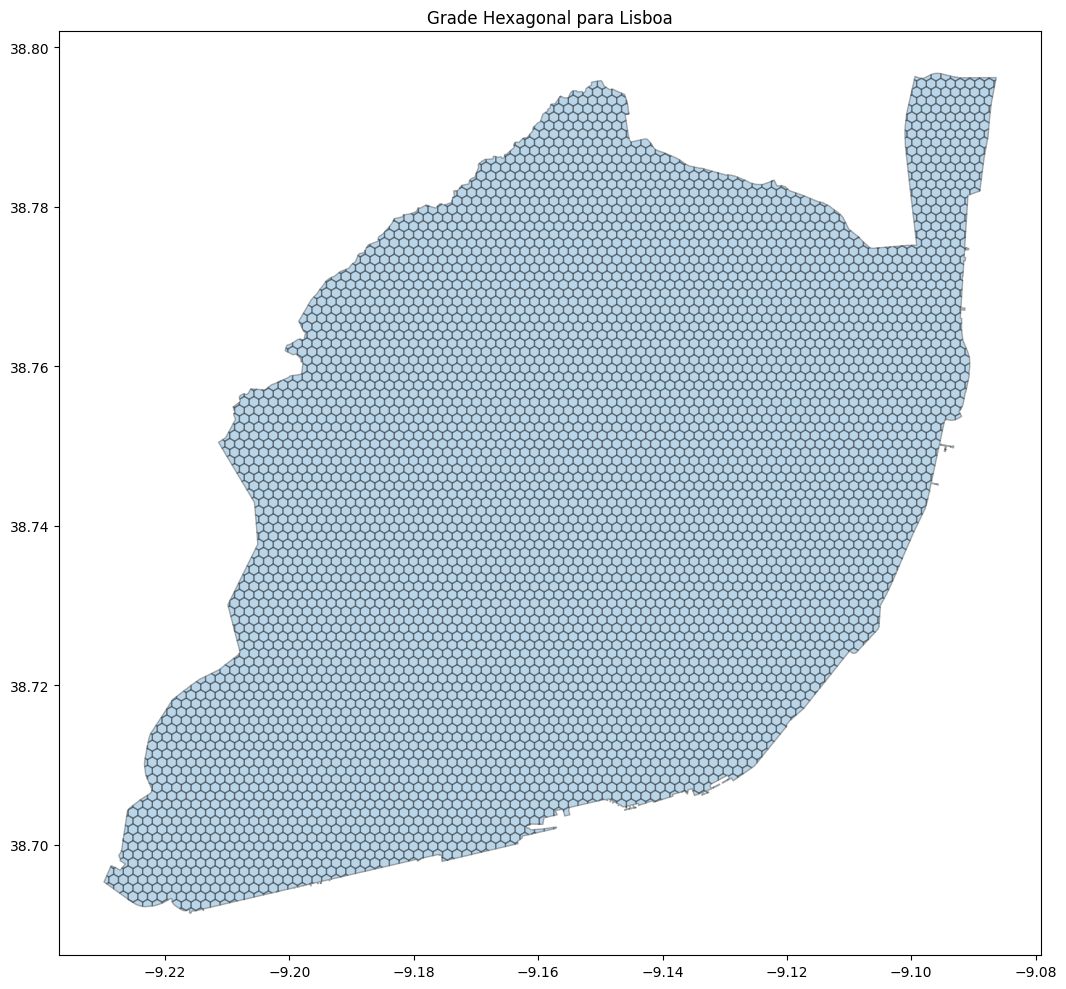

In [5]:
# Visualizar a grade hexagonal
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
hex_grid.plot(ax=ax, alpha=0.3, edgecolor='black')
plt.title('Grade Hexagonal para Lisboa')
plt.tight_layout()
plt.show()

## 4. Mapear Estações para Hexágonos com Distância Haversine

Agora vamos mapear cada estação de monitoramento para o hexágono mais próximo e, em seguida, interpolar valores para os hexágonos sem estações. Usaremos a distância haversine para cálculos geográficos mais precisos, considerando a curvatura da Terra.

## Nota Importante: Uso da Distância Haversine

Este notebook foi atualizado para utilizar a distância haversine em vez da distância euclidiana nos cálculos espaciais. Isso é particularmente importante ao trabalhar com coordenadas geográficas (latitude/longitude), pois:

1. **Precisão geográfica**: A distância haversine considera a curvatura da Terra, calculando a distância real sobre a superfície esférica do planeta.
2. **Resultados mais realistas**: Especialmente para áreas urbanas extensas como Lisboa, o uso de distância euclidiana em coordenadas geográficas pode levar a distorções significativas.
3. **Interpolação mais precisa**: A interpolação IDW (Inverse Distance Weighting) baseada em distâncias haversine produz um mapeamento de poluição mais realista.

Diferenças entre os métodos de cálculo de distância:
- **Euclidiana**: Calcula a distância em linha reta no plano cartesiano, ignorando a curvatura da Terra.
- **Haversine**: Calcula a distância do grande círculo entre dois pontos na superfície de uma esfera, considerando a curvatura terrestre.

Embora para áreas pequenas a diferença possa ser mínima, para áreas maiores como uma cidade inteira, o uso da distância haversine proporciona resultados significativamente mais precisos na interpolação espacial dos dados de qualidade do ar.

In [6]:
# Função para calcular a distância haversine entre dois pontos geográficos
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    """
    Calcula a distância haversine entre dois pontos na Terra.
    Considera a curvatura da Terra para cálculos de distância mais precisos.
    
    Parâmetros:
    lat1, lon1: Coordenadas do primeiro ponto (graus)
    lat2, lon2: Coordenadas do segundo ponto (graus)
    
    Retorna: Distância em metros
    """
    # Raio médio da Terra em metros
    R = 6371000
    
    # Converter graus para radianos
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    # Diferença entre latitudes e longitudes
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    
    # Fórmula haversine
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    distancia = R * c
    
    return distancia

# Converter os dados de qualidade do ar para um GeoDataFrame com geometria de ponto
geometry = [Point(lon, lat) for lon, lat in zip(dados_ar['lon'], dados_ar['lat'])]
estacoes_gdf = gpd.GeoDataFrame(dados_ar, geometry=geometry, crs="EPSG:4326")

# Garantir que ambos os GeoDataFrames tenham o mesmo CRS
hex_grid = hex_grid.to_crs("EPSG:4326")

# Função para encontrar o hexágono mais próximo para cada ponto usando distância haversine
def encontrar_hexagono_proximo(ponto, hexagonos):
    # Obter coordenadas do ponto
    lon_ponto, lat_ponto = ponto.x, ponto.y
    
    # Calcular distância haversine para cada hexágono
    distancias = []
    for hexagono in hexagonos.geometry:
        # Usar o centroide do hexágono para comparação
        centroide = hexagono.centroid
        lon_hex, lat_hex = centroide.x, centroide.y
        
        # Calcular a distância haversine
        dist = calcular_distancia_haversine(lat_ponto, lon_ponto, lat_hex, lon_hex)
        distancias.append(dist)
    
    # Encontrar o índice do hexágono mais próximo
    idx_mais_proximo = np.argmin(distancias)
    return hexagonos.iloc[idx_mais_proximo]

# Mapear cada estação para o hexágono mais próximo
hexagonos_mapeados = []
for idx, ponto in enumerate(estacoes_gdf.geometry):
    hexagono_proximo = encontrar_hexagono_proximo(ponto, hex_grid)
    # Criar dicionário com propriedades da estação e geometria do hexágono
    mapeamento = {
        'estacao_id': estacoes_gdf.iloc[idx]['estacao_id'],
        'nome': estacoes_gdf.iloc[idx]['nome'],
        'IQA': estacoes_gdf.iloc[idx]['IQA'],
        'risk_level': estacoes_gdf.iloc[idx]['risk_level'],
        'color': estacoes_gdf.iloc[idx]['color'],
        'NO2': estacoes_gdf.iloc[idx]['NO2'],
        'PM10': estacoes_gdf.iloc[idx]['PM10'],
        'PM25': estacoes_gdf.iloc[idx]['PM25'],
        'O3': estacoes_gdf.iloc[idx]['O3'],
        'hex_id': hexagono_proximo['hex_id'],
        'geometry': hexagono_proximo.geometry
    }
    hexagonos_mapeados.append(mapeamento)

# Criar um novo GeoDataFrame com os hexágonos mapeados
ar_hexagonos = gpd.GeoDataFrame(hexagonos_mapeados, geometry='geometry', crs="EPSG:4326")

# Verificar se há hexágonos com mais de uma estação (duplicados)
duplicados = ar_hexagonos['hex_id'].value_counts()
print(f"Número de hexágonos únicos: {len(duplicados)}")
print(f"Número de hexágonos com múltiplas estações: {sum(duplicados > 1)}")

# Mostrar os hexágonos com múltiplas estações, se houver
if sum(duplicados > 1) > 0:
    print("\nHexágonos com múltiplas estações:")
    print(duplicados[duplicados > 1].head(10))

Número de hexágonos únicos: 10
Número de hexágonos com múltiplas estações: 0


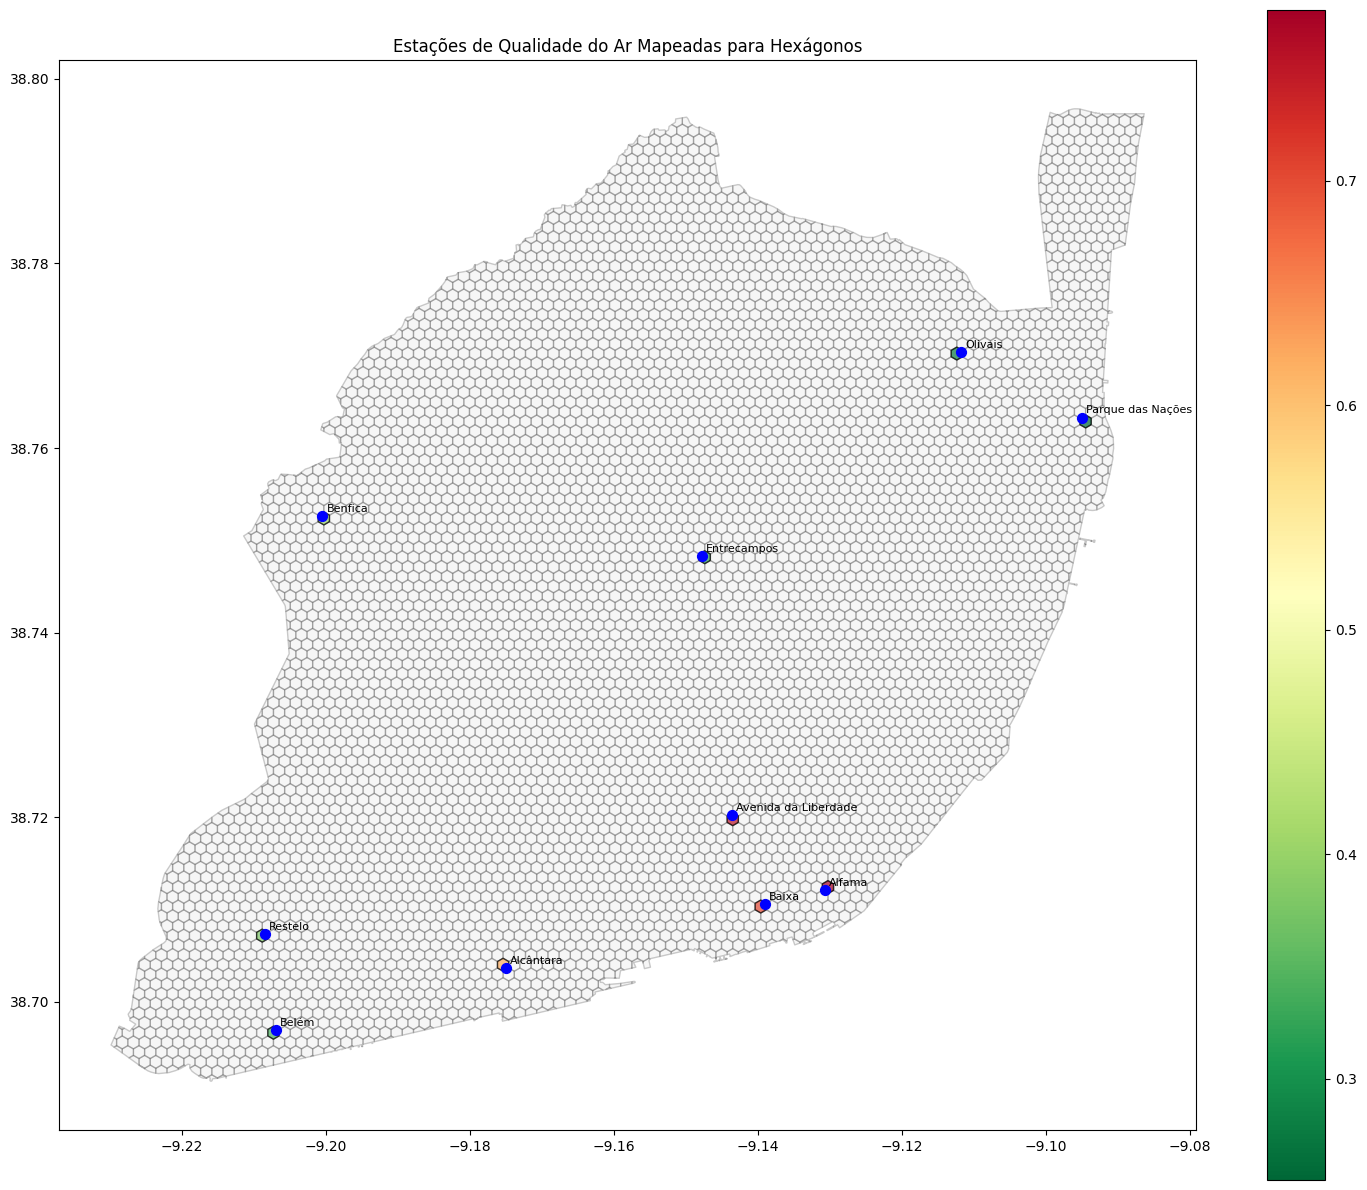

In [7]:
# Visualizar os pontos das estações e os hexágonos mapeados
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hex_grid.plot(ax=ax, alpha=0.2, edgecolor='black', color='lightgray')
ar_hexagonos.plot(ax=ax, alpha=0.7, edgecolor='black', column='IQA', cmap='RdYlGn_r', legend=True)
estacoes_gdf.plot(ax=ax, color='blue', markersize=50)

# Adicionar rótulos para as estações
for x, y, label in zip(estacoes_gdf.geometry.x, estacoes_gdf.geometry.y, estacoes_gdf['nome']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)

plt.title('Estações de Qualidade do Ar Mapeadas para Hexágonos')
plt.tight_layout()
plt.show()

## 5. Lidar com Hexágonos Duplicados

Se mais de uma estação foi mapeada para o mesmo hexágono, precisamos combinar essas informações.

In [8]:
# Lidar com hexágonos duplicados
if sum(duplicados > 1) > 0:
    # Agrupar por hex_id e agregar valores
    # Para IQA e níveis de risco: usamos o máximo (o pior)
    # Para outros poluentes: usamos a média
    agregacao = {
        'IQA': 'max',
        'risk_level': 'max',
        'NO2': 'mean',
        'PM10': 'mean',
        'PM25': 'mean',
        'O3': 'mean',
        'color': 'first',  # A cor é determinada pelo risk_level mais alto
        'geometry': 'first'
    }
    
    ar_hexagonos_unicos = ar_hexagonos.groupby('hex_id').agg(agregacao).reset_index()
    ar_hexagonos_unicos = gpd.GeoDataFrame(ar_hexagonos_unicos, geometry='geometry', crs="EPSG:4326")
else:
    ar_hexagonos_unicos = ar_hexagonos.copy()

print(f"Número de hexágonos após mesclagem: {len(ar_hexagonos_unicos)}")

Número de hexágonos após mesclagem: 10


## 6. Preencher Espaços em Branco (Interpolação Espacial com Haversine)

Agora vamos preencher os hexágonos vazios interpolando valores a partir das estações de monitoramento, utilizando a distância haversine para cálculos mais precisos.

In [9]:
# Identificar hexágonos na grade que não têm estações mapeadas
todos_hex_ids = set(hex_grid['hex_id'])
hex_ids_mapeados = set(ar_hexagonos_unicos['hex_id'])
hex_ids_vazios = todos_hex_ids - hex_ids_mapeados

print(f"Número de hexágonos na grade: {len(todos_hex_ids)}")
print(f"Número de hexágonos com dados: {len(hex_ids_mapeados)}")
print(f"Número de hexágonos vazios a preencher: {len(hex_ids_vazios)}")

# Função para preencher hexágonos vazios usando interpolação espacial com distância haversine
def preencher_hexagonos_vazios(hex_grid, ar_hexagonos, hex_ids_vazios):
    """
    Preenche hexágonos vazios interpolando valores dos hexágonos com dados.
    Usa ponderação por distância inversa (IDW) com distância haversine.
    """
    # Criar uma cópia dos hexágonos com dados
    hexagonos_preenchidos = ar_hexagonos.copy()
    
    # Obter hexágonos vazios da grade
    hexagonos_vazios = hex_grid[hex_grid['hex_id'].isin(hex_ids_vazios)].copy()
    
    # Para cada hexágono vazio, interpolar valores
    for idx, hexagono_vazio in hexagonos_vazios.iterrows():
        # Obter coordenadas do centroide do hexágono vazio
        centroide_vazio = hexagono_vazio.geometry.centroid
        lat_vazio, lon_vazio = centroide_vazio.y, centroide_vazio.x
        
        # Calcular distâncias haversine para todos os hexágonos com dados
        distancias = []
        for hex_geom in ar_hexagonos.geometry:
            centroide_hex = hex_geom.centroid
            lat_hex, lon_hex = centroide_hex.y, centroide_hex.x
            dist = calcular_distancia_haversine(lat_vazio, lon_vazio, lat_hex, lon_hex)
            distancias.append(dist)
        
        # Obter os N hexágonos mais próximos (ou todos se N > número disponível)
        n_proximos = min(5, len(distancias))
        indices_proximos = np.argsort(distancias)[:n_proximos]
        hexagonos_proximos = ar_hexagonos.iloc[indices_proximos]
        
        # Calcular pesos baseados na distância inversa
        pesos = 1.0 / np.array([distancias[i] for i in indices_proximos])
        pesos = pesos / pesos.sum()  # Normalizar pesos
        
        # Interpolar valores usando IDW
        iqa = float(np.sum(hexagonos_proximos['IQA'] * pesos))
        no2 = float(np.sum(hexagonos_proximos['NO2'] * pesos))
        pm10 = float(np.sum(hexagonos_proximos['PM10'] * pesos))
        pm25 = float(np.sum(hexagonos_proximos['PM25'] * pesos))
        o3 = float(np.sum(hexagonos_proximos['O3'] * pesos))
        
        # Determinar risk_level baseado no IQA interpolado
        if iqa <= 0.2:
            risk_level = 1
            color = '#ccff99'
        elif iqa <= 0.4:
            risk_level = 2
            color = '#ffff99'
        elif iqa <= 0.6:
            risk_level = 3
            color = '#ffcc99'
        elif iqa <= 0.8:
            risk_level = 4
            color = '#ff9999'
        else:
            risk_level = 5
            color = '#cc9999'
        
        # Criar nova linha para o hexágono preenchido
        novo_hexagono = {
            'hex_id': hexagono_vazio['hex_id'],
            'IQA': iqa,
            'risk_level': risk_level,
            'color': color,
            'NO2': no2,
            'PM10': pm10,
            'PM25': pm25,
            'O3': o3,
            'geometry': hexagono_vazio.geometry
        }
        
        # Adicionar aos hexágonos preenchidos
        hexagonos_preenchidos = pd.concat([hexagonos_preenchidos, 
                                          gpd.GeoDataFrame([novo_hexagono], 
                                                         geometry='geometry', 
                                                         crs="EPSG:4326")], 
                                         ignore_index=True)
    
    return hexagonos_preenchidos

# Preencher hexágonos vazios usando haversine
hexagonos_preenchidos = preencher_hexagonos_vazios(hex_grid, ar_hexagonos_unicos, hex_ids_vazios)

print(f"Número de hexágonos depois de preencher: {len(hexagonos_preenchidos)}")
print(f"Cobertura da grade hexagonal: {len(hexagonos_preenchidos) / len(hex_grid) * 100:.2f}%")

Número de hexágonos na grade: 5732
Número de hexágonos com dados: 10
Número de hexágonos vazios a preencher: 5722
Número de hexágonos depois de preencher: 5732
Cobertura da grade hexagonal: 100.00%


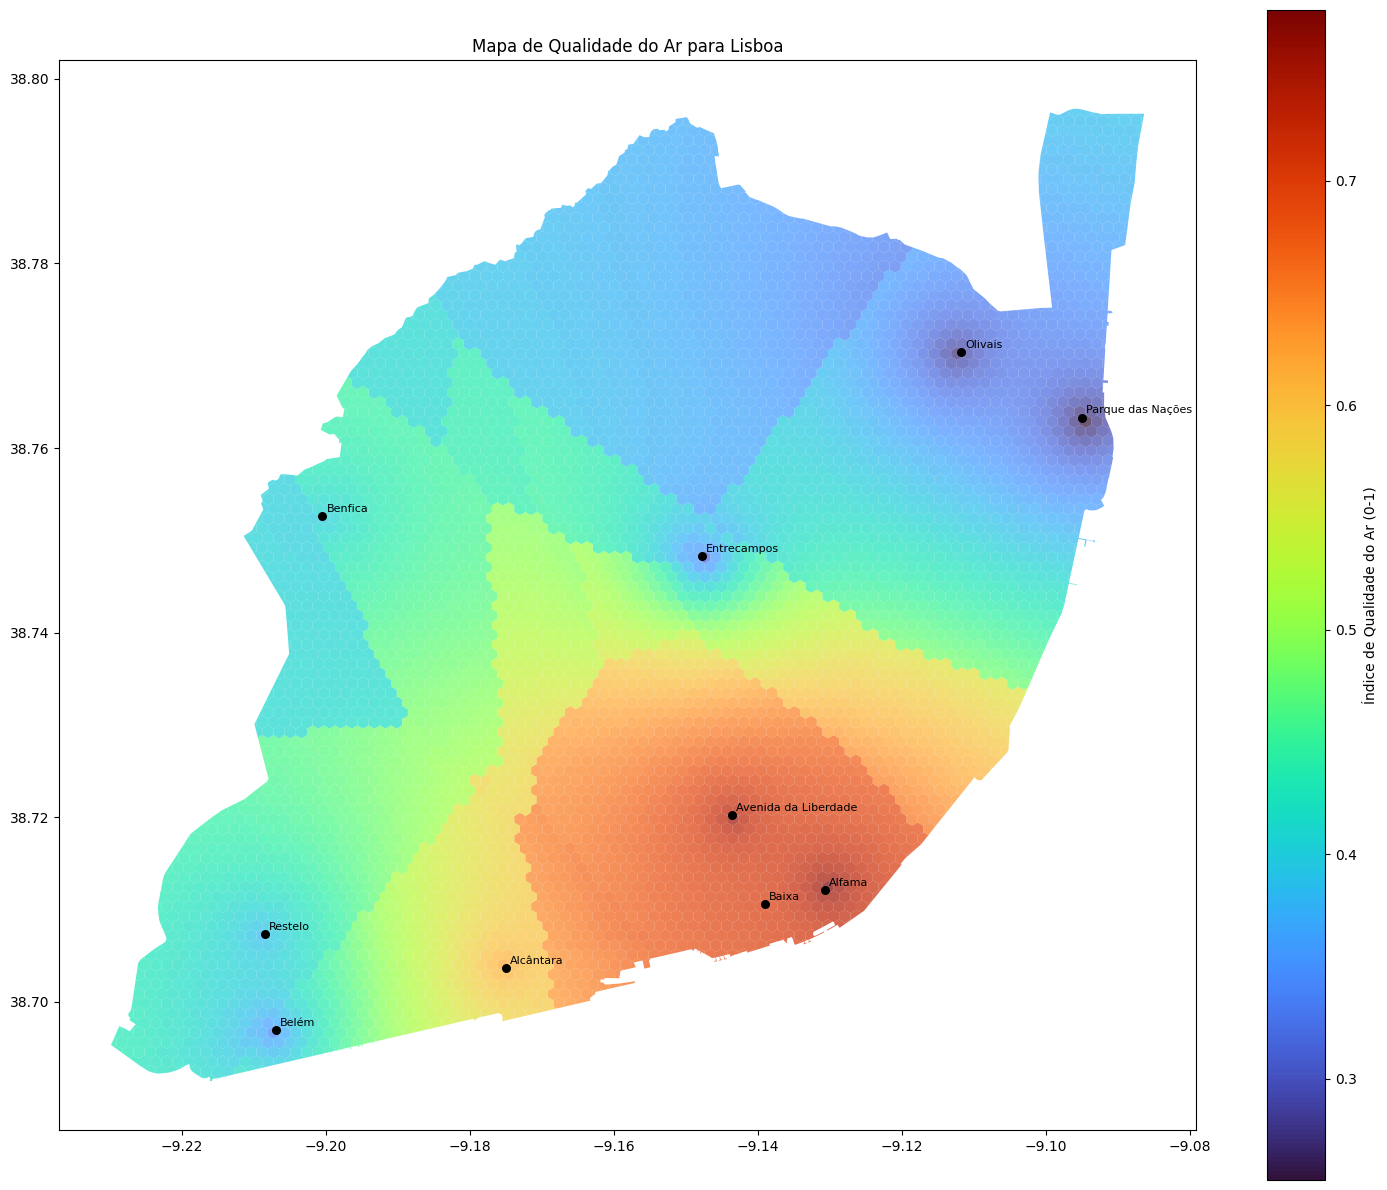

In [11]:
# Visualizar os hexágonos preenchidos
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hexagonos_preenchidos.plot(ax=ax, alpha=0.7, column='IQA', cmap='turbo', 
                          legend=True, legend_kwds={'label': 'Índice de Qualidade do Ar (0-1)'})
estacoes_gdf.plot(ax=ax, color='black', markersize=30)

# Adicionar rótulos para as estações
for x, y, label in zip(estacoes_gdf.geometry.x, estacoes_gdf.geometry.y, estacoes_gdf['nome']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)

plt.title('Mapa de Qualidade do Ar para Lisboa')
plt.tight_layout()
plt.show()

## 7. Finalizar e Salvar os Hexágonos de Qualidade do Ar

Vamos formatar os dados finais para serem compatíveis com o formato de saída do VERUS.

In [12]:
# Renomear e adicionar colunas para compatibilidade com VERUS
hexagonos_finais = hexagonos_preenchidos.rename(columns={
    'IQA': 'value'
})

# Reordenar colunas para clareza
ordem_colunas = ['hex_id', 'value', 'risk_level', 'color', 'NO2', 'PM10', 'PM25', 'O3']
hexagonos_finais = hexagonos_finais[ordem_colunas + [col for col in hexagonos_finais.columns 
                                               if col not in ordem_colunas]]

hexagonos_finais.head()

,hex_id,value,risk_level,color,NO2,PM10,PM25,O3,estacao_id,nome,geometry
0,h_2580,0.752,4,#ff9999,65.0,62.0,44.0,98.0,1.0,Avenida da Liberdade,"POLYGON ((-9.1427 38.71944, -9.14348 38.71909,..."
1,h_5102,0.320,2,#ffff99,52.0,14.0,16.0,89.0,2.0,Entrecampos,"POLYGON ((-9.14659 38.74782, -9.14737 38.74747..."
2,h_482,0.340,2,#ffff99,25.0,6.0,9.0,108.0,3.0,Belém,"POLYGON ((-9.2065 38.69631, -9.20727 38.69596,..."
3,h_6445,0.255,2,#ffff99,20.0,5.0,8.0,91.0,4.0,Parque das Nações,"POLYGON ((-9.09369 38.76253, -9.09447 38.76218..."
4,h_5442,0.400,2,#ffff99,33.0,19.0,20.0,89.0,5.0,Benfica,"POLYGON ((-9.1995 38.75202, -9.20027 38.75167,..."


In [13]:
# Salvar os hexágonos finais como GeoJSON
output_path = "../data/risk_layer/Lisboa_qualidade_ar_hexagonos.geojson"
hexagonos_finais.to_file(output_path, driver="GeoJSON")
print(f"Salvou hexágonos de qualidade do ar em {output_path}")

Salvou hexágonos de qualidade do ar em ../data/risk_layer/Lisboa_qualidade_ar_hexagonos.geojson


## 8. Visualizações Adicionais

Vamos criar visualizações adicionais para analisar a distribuição da qualidade do ar em Lisboa.

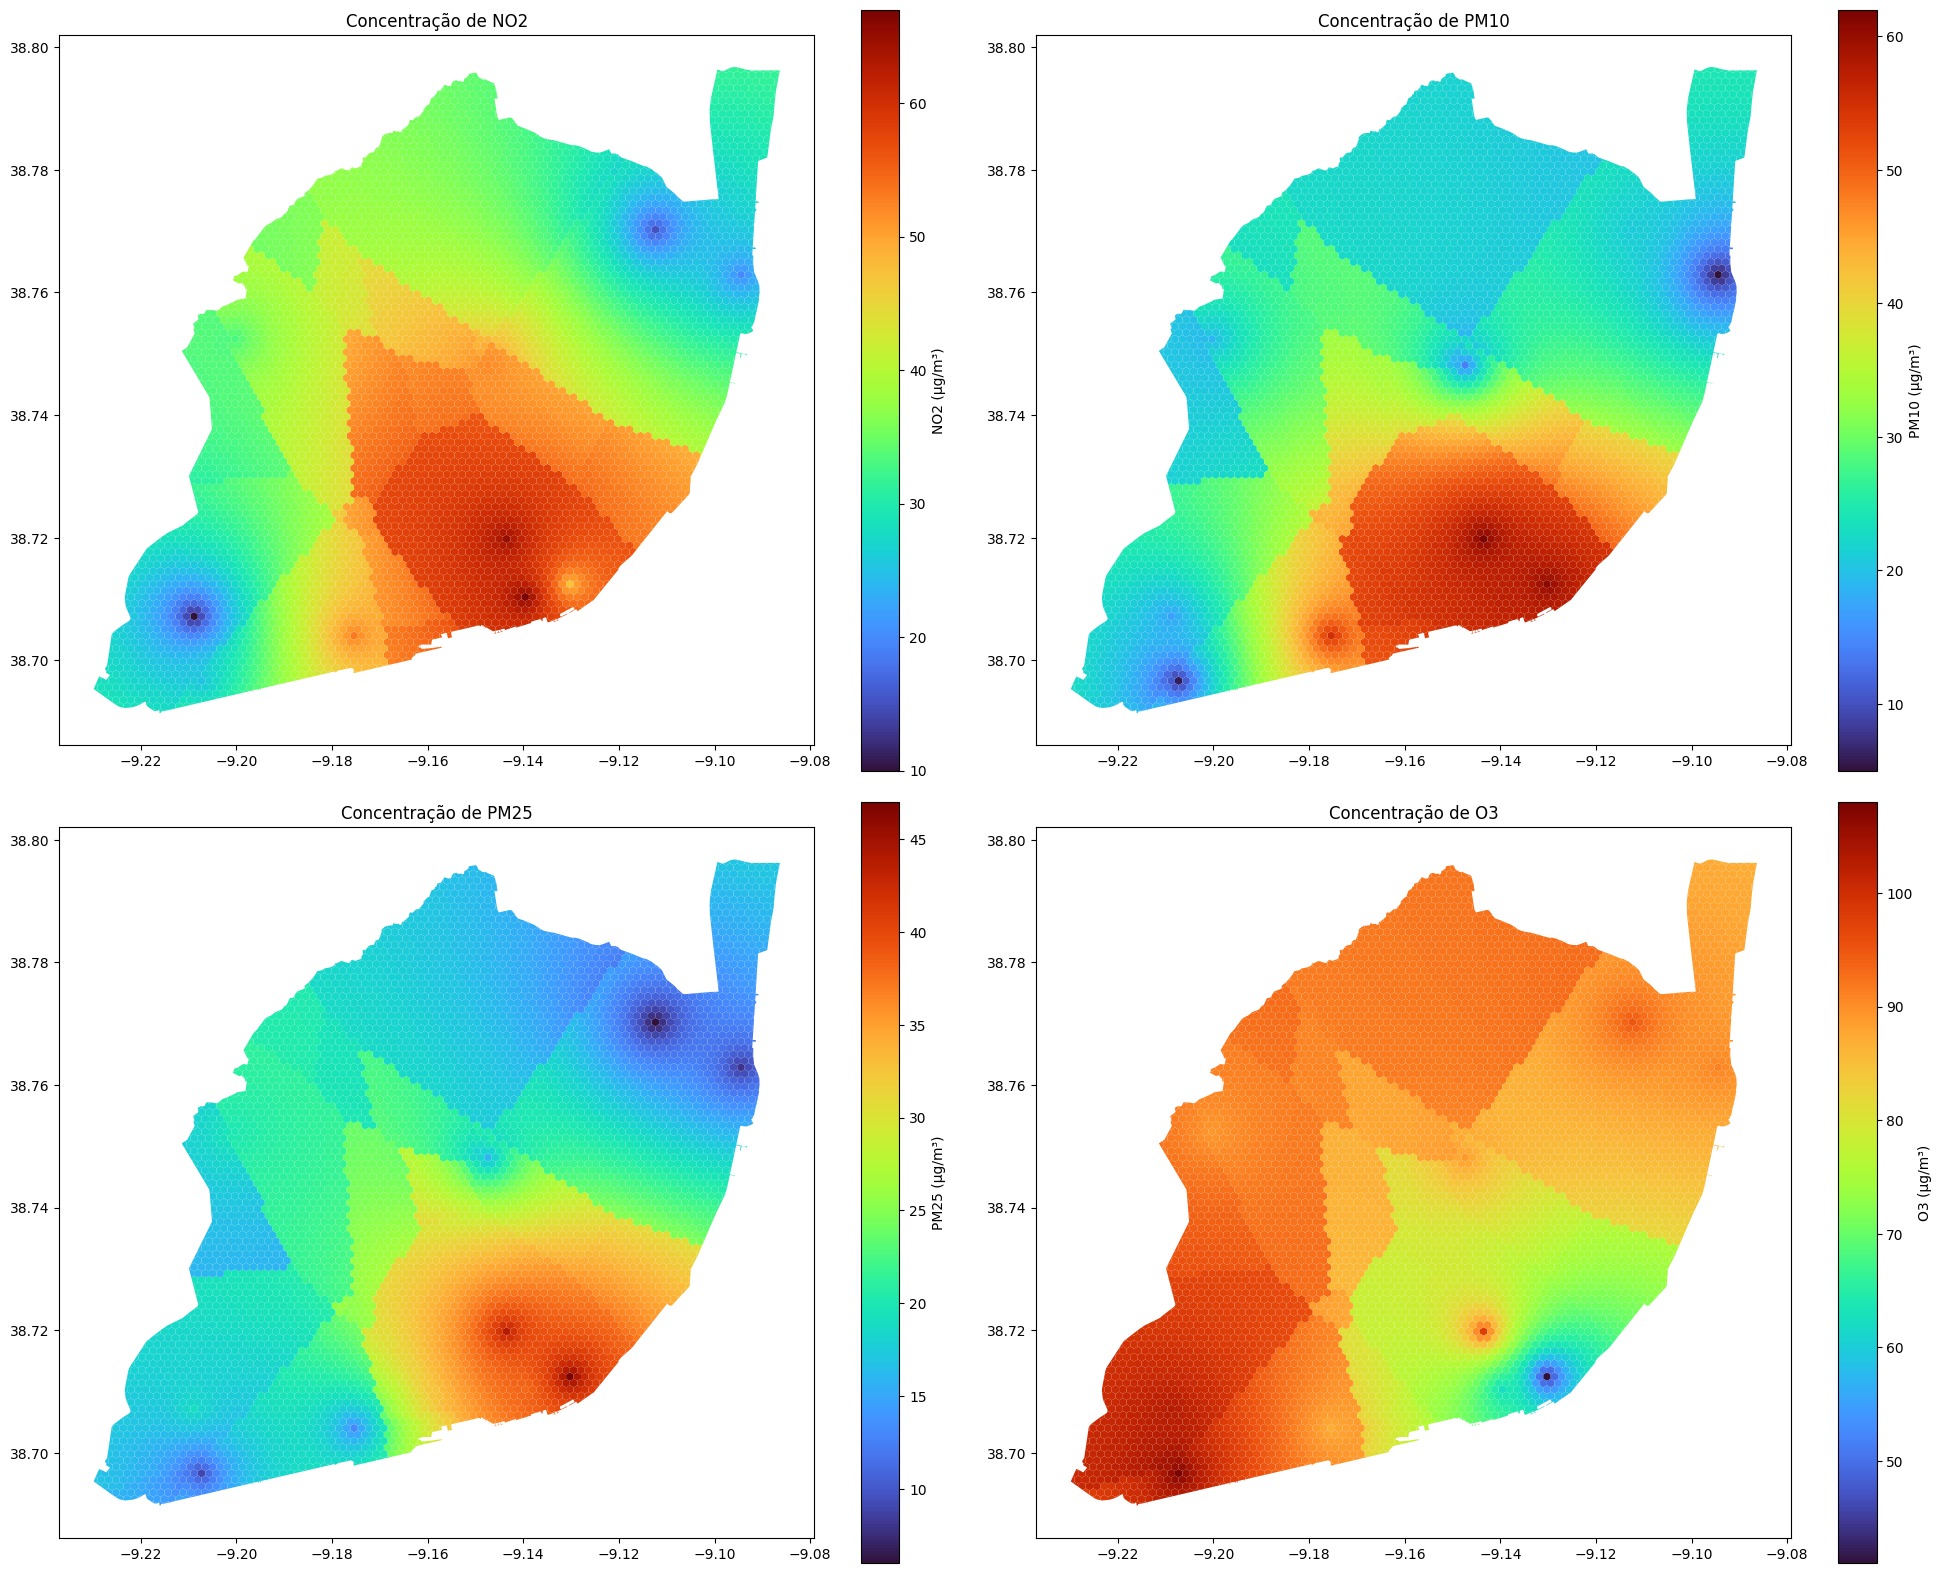

In [19]:
# Criar visualização para cada poluente principal
poluentes = ['NO2', 'PM10', 'PM25', 'O3']
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, poluente in enumerate(poluentes):
    hexagonos_finais.plot(ax=axes[i], column=poluente, cmap='turbo', 
                         legend=True, legend_kwds={'label': f'{poluente} (μg/m³)'})
    axes[i].set_title(f'Concentração de {poluente}')

plt.tight_layout()
plt.show()

## Análise Temporal dos Dados de Qualidade do Ar

Vamos analisar a distribuição temporal dos dados e implementar filtros para seleção de janelas de tempo, com foco nos horários de pico de tráfego.

Erro ao analisar distribuição temporal: [Errno 2] No such file or directory: '../data/risk_layer/lisbon.json'


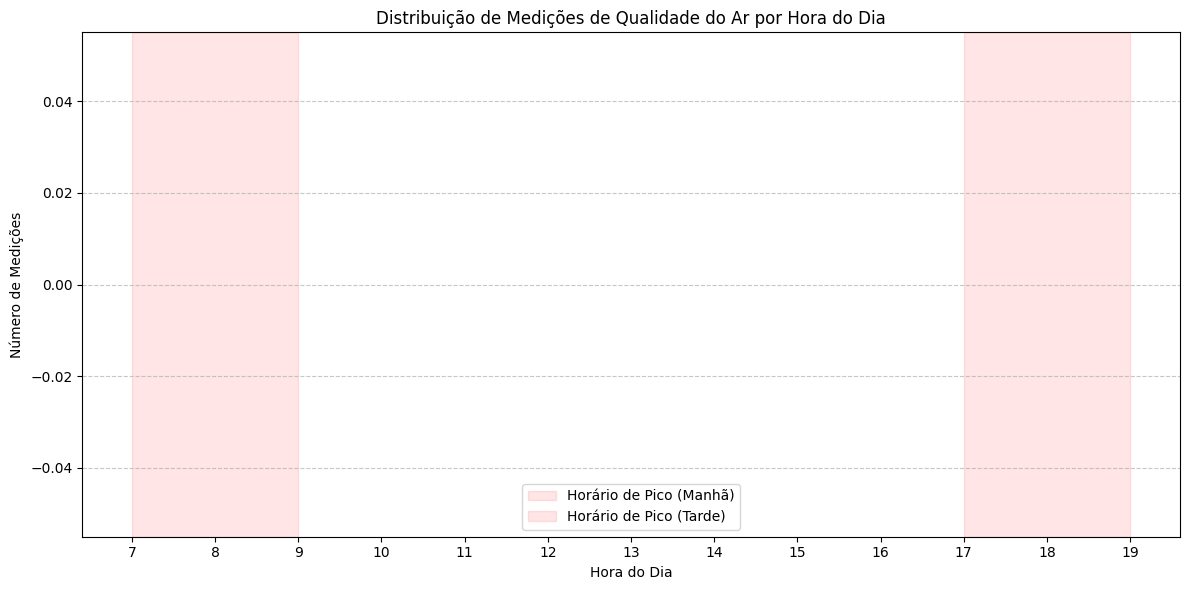


Estatísticas de medições por hora:


In [20]:
# Importar bibliotecas adicionais para manipulação de dados temporais
from datetime import datetime

# Função para converter o formato de data do JSON para um objeto datetime
def converter_data(data_str):
    """
    Converte uma string de data no formato "YYYYMMDDHHMI" para um objeto datetime.
    Exemplo: "202505150300" -> datetime(2025, 05, 15, 03, 00)
    """
    if not data_str or len(data_str) != 12:
        return None
    
    try:
        ano = int(data_str[0:4])
        mes = int(data_str[4:6])
        dia = int(data_str[6:8])
        hora = int(data_str[8:10])
        minuto = int(data_str[10:12])
        
        return datetime(ano, mes, dia, hora, minuto)
    except ValueError:
        print(f"Erro ao converter data: {data_str}")
        return None

# Analisar a distribuição temporal dos dados do arquivo JSON
def analisar_distribuicao_temporal():
    """
    Analisa a distribuição temporal dos dados no arquivo JSON.
    Retorna um dicionário com contagem de medições por hora do dia.
    """
    try:
        # Carregar dados do arquivo JSON
        json_path = "../data/risk_layer/lisbon.json"
        with open(json_path, 'r') as f:
            dados_json = json.load(f)
        
        # Contadores
        contagem_por_hora = {h: 0 for h in range(24)}
        registros_qa = []
        
        # Analisar cada registro
        for registro in dados_json:
            data_str = registro.get('date')
            if data_str and registro.get('id', '').startswith('QA'):
                data = converter_data(data_str)
                if data:
                    contagem_por_hora[data.hour] += 1
                    # Guardar registros de qualidade do ar com data válida
                    registros_qa.append({
                        'id': registro.get('id'),
                        'data': data,
                        'hora': data.hour,
                        'valor': registro.get('value'),
                        'poluente': registro.get('id')[2:6].strip('0'),
                        'estacao': registro.get('id')[-4:],
                        'endereco': registro.get('address'),
                        'lat': registro.get('coordinates', {}).get('lat', 0),
                        'lon': registro.get('coordinates', {}).get('lng', 0)
                    })
        
        print(f"Registros de qualidade do ar analisados: {len(registros_qa)}")
        
        # Converter para DataFrame
        df_qa = pd.DataFrame(registros_qa)
        
        return contagem_por_hora, df_qa
    
    except Exception as e:
        print(f"Erro ao analisar distribuição temporal: {e}")
        return {}, pd.DataFrame()

# Executar a análise temporal
contagem_por_hora, df_qa = analisar_distribuicao_temporal()

# Visualizar a distribuição de medições por hora
plt.figure(figsize=(12, 6))
horas = list(contagem_por_hora.keys())
contagens = list(contagem_por_hora.values())

# Destacar os horários de pico (assumindo 7-9h e 17-19h como picos de tráfego)
cores = ['#ff9999' if (hora >= 7 and hora <= 9) or (hora >= 17 and hora <= 19) else '#1f77b4' 
         for hora in horas]

plt.bar(horas, contagens, color=cores)
plt.title('Distribuição de Medições de Qualidade do Ar por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Medições')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar anotações para os períodos de pico
plt.axvspan(7, 9, alpha=0.1, color='red', label='Horário de Pico (Manhã)')
plt.axvspan(17, 19, alpha=0.1, color='red', label='Horário de Pico (Tarde)')
plt.legend()

plt.tight_layout()
plt.show()

# Exibir estatísticas das medições por hora
print("\nEstatísticas de medições por hora:")
for hora, contagem in sorted(contagem_por_hora.items()):
    pico = " (PICO)" if (hora >= 7 and hora <= 9) or (hora >= 17 and hora <= 19) else ""
    print(f"Hora {hora:02d}:00 - {contagem} medições{pico}")

# Mostrar o DataFrame resultante
if not df_qa.empty:
    print("\nExemplos de registros de qualidade do ar:")
    print(df_qa.head())

In [21]:
# Função para filtrar os dados por janela de tempo
def filtrar_por_janela_tempo(df_qa, inicio_hora, fim_hora):
    """
    Filtra os registros de qualidade do ar para uma janela de tempo específica.
    
    Parâmetros:
    df_qa: DataFrame com os registros de qualidade do ar
    inicio_hora: Hora de início (0-23)
    fim_hora: Hora de fim (0-23)
    
    Retorna: DataFrame filtrado
    """
    return df_qa[(df_qa['hora'] >= inicio_hora) & (df_qa['hora'] <= fim_hora)]

# Definir janelas de tempo para análise
janelas_tempo = {
    'Manhã (Pico)': (7, 9),
    'Tarde (Pico)': (17, 19),
    'Noite': (22, 5),
    'Meio-dia': (11, 14),
    'Dia Completo': (0, 23)
}

# Filtrar dados para cada janela de tempo e mostrar estatísticas
print("Estatísticas de medições por janela de tempo:")
for nome, (inicio, fim) in janelas_tempo.items():
    df_filtrado = filtrar_por_janela_tempo(df_qa, inicio, fim)
    print(f"\n{nome} ({inicio:02d}h-{fim:02d}h): {len(df_filtrado)} medições")
    
    # Exibir estatísticas por poluente se houver dados
    if not df_filtrado.empty:
        estatisticas = df_filtrado.groupby('poluente')['valor'].agg(['count', 'mean', 'min', 'max'])
        print(estatisticas)

Estatísticas de medições por janela de tempo:


KeyError: 'hora'

In [ ]:
# Função para obter dados de qualidade do ar para uma janela de tempo específica
def obter_dados_qualidade_ar_filtrados(janela_tempo):
    """
    Obtém dados de qualidade do ar para Lisboa para uma janela de tempo específica.
    
    Parâmetros:
    janela_tempo: Tupla (hora_inicio, hora_fim) para filtrar os dados
    
    Retorna: DataFrame com os dados organizados por estação
    """
    try:
        # Carregar dados do arquivo JSON
        json_path = "../data/risk_layer/lisbon.json"
        
        with open(json_path, 'r') as f:
            dados_json = json.load(f)
            
        # Extrair estações de monitoramento de qualidade do ar
        estacoes = {}
        
        # Filtrar por janela de tempo e identificar registros de qualidade do ar
        for registro in dados_json:
            id_registro = registro.get('id', '')
            
            # Verificar se é um registro de qualidade do ar
            if id_registro.startswith('QA'):
                # Verificar se está na janela de tempo especificada
                data_str = registro.get('date')
                if data_str:
                    data = converter_data(data_str)
                    inicio_hora, fim_hora = janela_tempo
                    
                    # Se a hora final é menor que a inicial, significa que está cruzando a meia-noite
                    if inicio_hora > fim_hora:
                        em_janela = data.hour >= inicio_hora or data.hour <= fim_hora
                    else:
                        em_janela = data.hour >= inicio_hora and data.hour <= fim_hora
                    
                    if data and em_janela:
                        # Extrair o número da estação (últimos 4 dígitos)
                        num_estacao = id_registro[-4:]
                        endereco = registro.get('address', f'Estação {num_estacao}')
                        
                        # Inicializar a estação se não existir
                        if num_estacao not in estacoes:
                            estacoes[num_estacao] = {
                                'estacao_id': num_estacao,
                                'nome': endereco,
                                'lat': registro.get('coordinates', {}).get('lat', 0),
                                'lon': registro.get('coordinates', {}).get('lng', 0),
                                'NO2': None,
                                'PM10': None,
                                'PM25': None,
                                'O3': None,
                                'hora': data.hour  # Guardar a hora para referência
                            }
                        
                        # Adicionar o valor do poluente
                        if 'PM25' in id_registro:
                            estacoes[num_estacao]['PM25'] = registro.get('value')
                        elif 'PM10' in id_registro:
                            estacoes[num_estacao]['PM10'] = registro.get('value')
                        elif 'NO2' in id_registro:
                            estacoes[num_estacao]['NO2'] = registro.get('value')
                        elif 'O3' in id_registro:
                            estacoes[num_estacao]['O3'] = registro.get('value')
        
        # Converter para DataFrame
        df_estacoes = pd.DataFrame(list(estacoes.values()))
        
        # Se não houver dados suficientes, usar todos os dados disponíveis
        if df_estacoes.empty or len(df_estacoes) < 5:
            print(f"Poucos dados para janela {inicio_hora}-{fim_hora}h, usando dados completos")
            return obter_dados_qualidade_ar()
        
        print(f"Dados filtrados para janela {inicio_hora}-{fim_hora}h: {len(df_estacoes)} estações")
        
        # Preencher valores ausentes com médias ou valores padrão
        if df_estacoes.isna().any().any():
            for poluente in ['NO2', 'PM10', 'PM25', 'O3']:
                if poluente in df_estacoes.columns:
                    # Usar a média dos valores disponíveis ou um valor padrão
                    media = df_estacoes[poluente].mean()
                    valor_padrao = {
                        'NO2': 40,
                        'PM10': 30,
                        'PM25': 15,
                        'O3': 80
                    }.get(poluente)
                    
                    df_estacoes[poluente] = df_estacoes[poluente].fillna(
                        media if not pd.isna(media) else valor_padrao
                    )
        
        return df_estacoes
        
    except Exception as e:
        print(f"Erro ao carregar dados filtrados: {e}")
        return gerar_dados_simulados()

In [ ]:
# Função para processar e visualizar os dados para uma janela de tempo específica usando haversine
def processar_janela_tempo(nome_janela, janela_tempo):
    """
    Processa e visualiza os dados de qualidade do ar para uma janela de tempo específica,
    utilizando distância haversine para cálculos mais precisos.
    
    Parâmetros:
    nome_janela: Nome descritivo da janela de tempo
    janela_tempo: Tupla (hora_inicio, hora_fim)
    """
    print(f"\n{'=' * 50}")
    print(f"Processando dados para {nome_janela} ({janela_tempo[0]:02d}h-{janela_tempo[1]:02d}h)")
    print(f"{'=' * 50}")
    
    # Obter dados filtrados para a janela de tempo
    dados_ar = obter_dados_qualidade_ar_filtrados(janela_tempo)
    
    # Se não houver dados suficientes, pular esta janela
    if dados_ar.empty:
        print(f"Sem dados suficientes para {nome_janela}")
        return None
    
    # Calcular o IQA
    dados_ar['IQA'] = dados_ar.apply(calcular_iqa, axis=1)
    
    # Calcular níveis de risco
    dados_ar['risk_level'] = pd.cut(
        dados_ar['IQA'], 
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
        labels=[1, 2, 3, 4, 5]
    ).astype(int)
    
    # Atribuir cores
    cores = {
        1: '#ccff99',  # Verde claro - Muito Bom
        2: '#ffff99',  # Amarelo claro - Bom
        3: '#ffcc99',  # Laranja claro - Médio
        4: '#ff9999',  # Vermelho claro - Fraco
        5: '#cc9999'   # Vermelho escuro - Muito Fraco/Mau
    }
    dados_ar['color'] = dados_ar['risk_level'].map(cores)
    
    # Converter para GeoDataFrame
    geometry = [Point(lon, lat) for lon, lat in zip(dados_ar['lon'], dados_ar['lat'])]
    estacoes_gdf = gpd.GeoDataFrame(dados_ar, geometry=geometry, crs="EPSG:4326")
    
    # Mapear para hexágonos usando haversine
    hexagonos_mapeados = []
    for idx, ponto in enumerate(estacoes_gdf.geometry):
        hexagono_proximo = encontrar_hexagono_proximo(ponto, hex_grid)
        mapeamento = {
            'estacao_id': estacoes_gdf.iloc[idx]['estacao_id'],
            'nome': estacoes_gdf.iloc[idx]['nome'],
            'IQA': estacoes_gdf.iloc[idx]['IQA'],
            'risk_level': estacoes_gdf.iloc[idx]['risk_level'],
            'color': estacoes_gdf.iloc[idx]['color'],
            'NO2': estacoes_gdf.iloc[idx]['NO2'],
            'PM10': estacoes_gdf.iloc[idx]['PM10'],
            'PM25': estacoes_gdf.iloc[idx]['PM25'],
            'O3': estacoes_gdf.iloc[idx]['O3'],
            'hex_id': hexagono_proximo['hex_id'],
            'geometry': hexagono_proximo.geometry
        }
        hexagonos_mapeados.append(mapeamento)
    
    # Criar GeoDataFrame dos hexágonos mapeados
    ar_hexagonos = gpd.GeoDataFrame(hexagonos_mapeados, geometry='geometry', crs="EPSG:4326")
    
    # Lidar com hexágonos duplicados
    duplicados = ar_hexagonos['hex_id'].value_counts()
    if sum(duplicados > 1) > 0:
        agregacao = {
            'IQA': 'max',
            'risk_level': 'max',
            'NO2': 'mean',
            'PM10': 'mean',
            'PM25': 'mean',
            'O3': 'mean',
            'color': 'first',
            'geometry': 'first'
        }
        
        ar_hexagonos_unicos = ar_hexagonos.groupby('hex_id').agg(agregacao).reset_index()
        ar_hexagonos_unicos = gpd.GeoDataFrame(ar_hexagonos_unicos, geometry='geometry', crs="EPSG:4326")
    else:
        ar_hexagonos_unicos = ar_hexagonos.copy()
    
    # Preencher hexágonos vazios usando haversine
    todos_hex_ids = set(hex_grid['hex_id'])
    hex_ids_mapeados = set(ar_hexagonos_unicos['hex_id'])
    hex_ids_vazios = todos_hex_ids - hex_ids_mapeados
    
    hexagonos_preenchidos = preencher_hexagonos_vazios(hex_grid, ar_hexagonos_unicos, hex_ids_vazios)
    
    # Visualizar mapa
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    hexagonos_preenchidos.plot(ax=ax, alpha=0.7, column='IQA', cmap='RdYlGn_r', 
                             legend=True, legend_kwds={'label': 'Índice de Qualidade do Ar (0-1)'})
    estacoes_gdf.plot(ax=ax, color='black', markersize=30)
    
    plt.title(f'Mapa de Qualidade do Ar para Lisboa - {nome_janela} ({janela_tempo[0]:02d}h-{janela_tempo[1]:02d}h)\nUtilizando Interpolação com Distância Haversine')
    plt.tight_layout()
    plt.show()
    
    # Estatísticas básicas
    print(f"\nEstatísticas para {nome_janela}:")
    estatisticas = hexagonos_preenchidos[['IQA']].describe()
    print(estatisticas)
    
    # Contagem por nível de risco
    contagem_por_risco = hexagonos_preenchidos['risk_level'].value_counts().sort_index()
    print("\nDistribuição por nível de risco:")
    print(contagem_por_risco)
    
    # Retornar os dados processados
    return {
        'nome': nome_janela,
        'janela': janela_tempo,
        'dados': hexagonos_preenchidos
    }